In [24]:
import random
from matplotlib import pyplot as plt
import numpy as np
from numpy import random
from sklearn.datasets import load_iris
import pandas as pd
from scipy.stats import multivariate_normal
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import seaborn as sns
import itertools
from scipy import linalg
import matplotlib.patheffects as PathEffects
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture
import re

# 2. Phần mô hình trộn Gaussian (Gaussian Mixture Model)

## 2.1. Thuật toán EM - Xây dựng chương trình từ numpy

In [3]:
class GMM():
    def __init__(self, k, dim, init_mu=None, init_sigma=None, init_pi=None, colors=None):
        '''
        Define a model with known number of clusters and dimensions.
        input:
            - k: Number of Gaussian clusters
            - dim: Dimension 
            - init_mu: initial value of mean of clusters (k, dim)
                       (default) random from uniform[-10, 10]
            - init_sigma: initial value of covariance matrix of clusters (k, dim, dim)
                          (default) Identity matrix for each cluster
            - init_pi: initial value of cluster weights (k,)
                       (default) equal value to all cluster i.e. 1/k
            - colors: Color valu for plotting each cluster (k, 3)
                      (default) random from uniform[0, 1]
        '''
        self.k = k
        self.dim = dim
        if(init_mu is None):
            init_mu = random.rand(k, dim)*20 - 10
        self.mu = init_mu
        if(init_sigma is None):
            init_sigma = np.zeros((k, dim, dim))
            for i in range(k):
                init_sigma[i] = np.eye(dim)
        self.sigma = init_sigma
        if(init_pi is None):
            init_pi = np.ones(self.k)/self.k
        self.pi = init_pi
        if(colors is None):
            colors = random.rand(k, 3)
            for i in range(k):
                colors[i, 2] = i/k
        self.colors = colors
    
    def init_em(self, X):
        '''
        Initialization for EM algorithm.
        input:
            - X: data (batch_size, dim)
        '''
        self.data = X
        self.num_points = X.shape[0]
        self.z = np.zeros((self.num_points, self.k))
    
    def e_step(self):
        '''
        E-step of EM algorithm.
        '''
        for i in range(self.k):
            # allow_singular=True to avoid errors when covariance is singular
            self.z[:, i] = self.pi[i] * multivariate_normal.pdf(self.data, mean=self.mu[i], cov=self.sigma[i], allow_singular=True)
        self.z /= self.z.sum(axis=1, keepdims=True)
    
    def m_step(self):
        '''
        M-step of EM algorithm.
        '''
        eps = 1e-8
        sum_z = self.z.sum(axis=0)
        # avoid division by zero by using a safe copy
        sum_z_safe = sum_z.copy()
        sum_z_safe[sum_z_safe == 0] = eps
        self.pi = sum_z / self.num_points
        self.mu = np.matmul(self.z.T, self.data)
        self.mu /= sum_z_safe[:, None]
        for i in range(self.k):
            j = np.expand_dims(self.data, axis=1) - self.mu[i]
            s = np.matmul(j.transpose([0, 2, 1]), j)
            self.sigma[i] = np.matmul(s.transpose(1, 2, 0), self.z[:, i] )
            self.sigma[i] /= sum_z_safe[i]
            # regularize covariance to ensure positive-definiteness
            self.sigma[i] += np.eye(self.dim) * 1e-6
            
    def log_likelihood(self, X):
        '''
        Compute the log-likelihood of X under current parameters
        input:
            - X: Data (batch_size, dim)
        output:
            - log-likelihood of X: Sum_n Sum_k log(pi_k * N( X_n | mu_k, sigma_k ))
        '''
        ll = []
        for d in X:
            tot = 0
            for i in range(self.k):
                # allow_singular=True to avoid LinAlgError on singular covariances
                tot += self.pi[i] * multivariate_normal.pdf(d, mean=self.mu[i], cov=self.sigma[i], allow_singular=True)
            ll.append(np.log(tot))
        return np.sum(ll)
    
    def plot_gaussian(self, mean, cov, ax, n_std=3.0, facecolor='none', **kwargs):
        '''
        Utility function to plot one Gaussian from mean and covariance.
        '''
        pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
        ell_radius_x = np.sqrt(1 + pearson)
        ell_radius_y = np.sqrt(1 - pearson)
        ellipse = Ellipse((0, 0),
            width=ell_radius_x * 2,
            height=ell_radius_y * 2,
            facecolor=facecolor,
            **kwargs)
        scale_x = np.sqrt(cov[0, 0]) * n_std
        mean_x = mean[0]
        scale_y = np.sqrt(cov[1, 1]) * n_std
        mean_y = mean[1]
        transf = transforms.Affine2D() \
            .rotate_deg(45) \
            .scale(scale_x, scale_y) \
            .translate(mean_x, mean_y)
        ellipse.set_transform(transf + ax.transData)
        return ax.add_patch(ellipse)

    def draw(self, ax, n_std=2.0, facecolor='none', **kwargs):
        '''
        Function to draw the Gaussians.
        Note: Only for two-dimensionl dataset
        '''
        if(self.dim != 2):
            print("Drawing available only for 2D case.")
            return
        for i in range(self.k):
            self.plot_gaussian(self.mu[i], self.sigma[i], ax, n_std=n_std, edgecolor=self.colors[i], **kwargs)


In [4]:
def gen_data(k=3, dim=2, points_per_cluster=200, lim=[-10, 10]):
    '''
    Generates data from a random mixture of Gaussians in a given range.
    Will also plot the points in case of 2D.
    input:
        - k: Number of Gaussian clusters
        - dim: Dimension of generated points
        - points_per_cluster: Number of points to be generated for each cluster
        - lim: Range of mean values
    output:
        - X: Generated points (points_per_cluster*k, dim)
    '''
    x = []
    mean = random.rand(k, dim)*(lim[1]-lim[0]) + lim[0]
    for i in range(k):
        cov = random.rand(dim, dim+10)
        cov = np.matmul(cov, cov.T)
        _x = np.random.multivariate_normal(mean[i], cov, points_per_cluster)
        x += list(_x)
    x = np.array(x)
    if(dim == 2):
        fig = plt.figure()
        ax = fig.gca()
        ax.scatter(x[:,0], x[:,1], s=3, alpha=0.4)
        ax.autoscale(enable=True) 
    return x

In [5]:
def plot(title):
    '''
    Draw the data points and the fitted mixture model.
    input:
        - title: title of plot.
    '''
    fig = plt.figure(figsize=(8, 8))
    ax = fig.gca()
    # Prefer plotting the data attached to gmm (gmm.data) if available, otherwise fall back to X_example1
    data_for_plot = getattr(gmm, 'data', None)
    if data_for_plot is None:
        try:
            data_for_plot = X_example1
        except NameError:
            raise RuntimeError('No data available for plotting. Ensure either gmm.init_em(...) was called or X_example1 exists.')

    ax.scatter(data_for_plot[:, 0], data_for_plot[:, 1], s=3, alpha=0.4)
    ax.scatter(gmm.mu[:, 0], gmm.mu[:, 1], c=gmm.colors)
    gmm.draw(ax, lw=3)
    ax.set_xlim((-22, 22))
    ax.set_ylim((-22, 22))
    
    plt.title(title)
    # Removed automatic saving of iteration plots to files
    plt.show()
    plt.clf()


Generated synthetic data X_example1 with shape: (3000, 2)


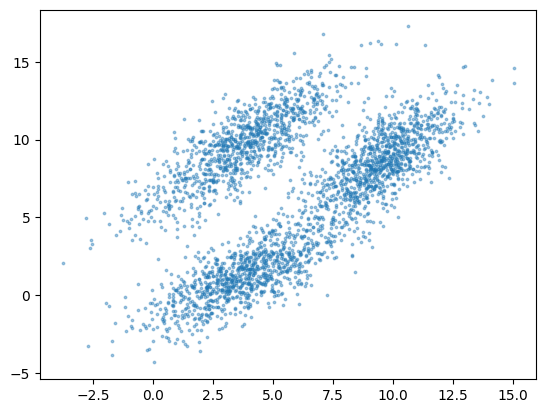

In [6]:
# Generate random 2D data with 3 clusters 
X_example1 = gen_data(k=3, dim=2, points_per_cluster=1000)
print(f"Generated synthetic data X_example1 with shape: {X_example1.shape}")

In [7]:
# Create a Gaussian Mixture Model
gmm = GMM(3, 2)

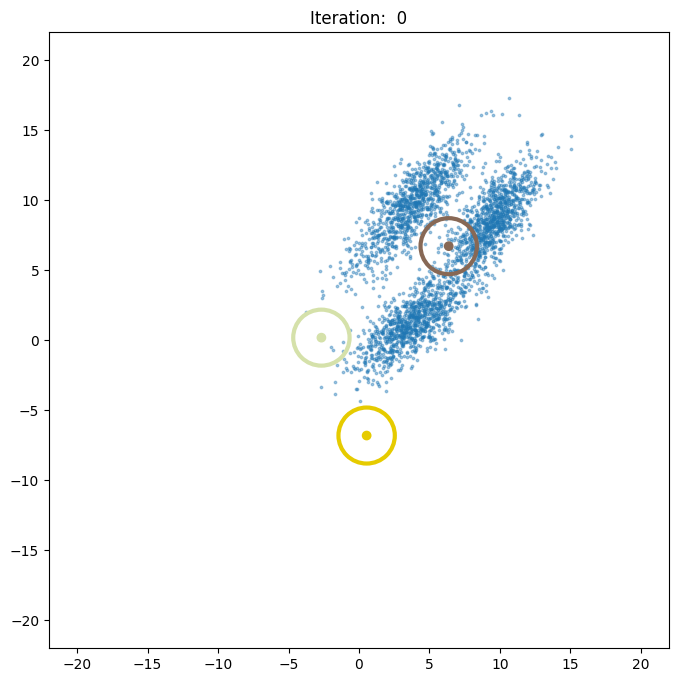

Iteration: 1, log-likelihood: -15912.3672


<Figure size 640x480 with 0 Axes>

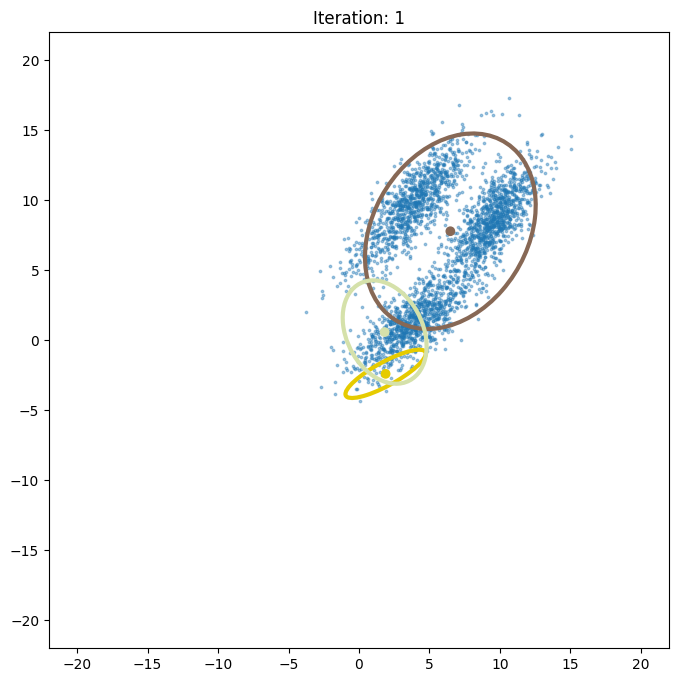

Iteration: 2, log-likelihood: -15690.1611


<Figure size 640x480 with 0 Axes>

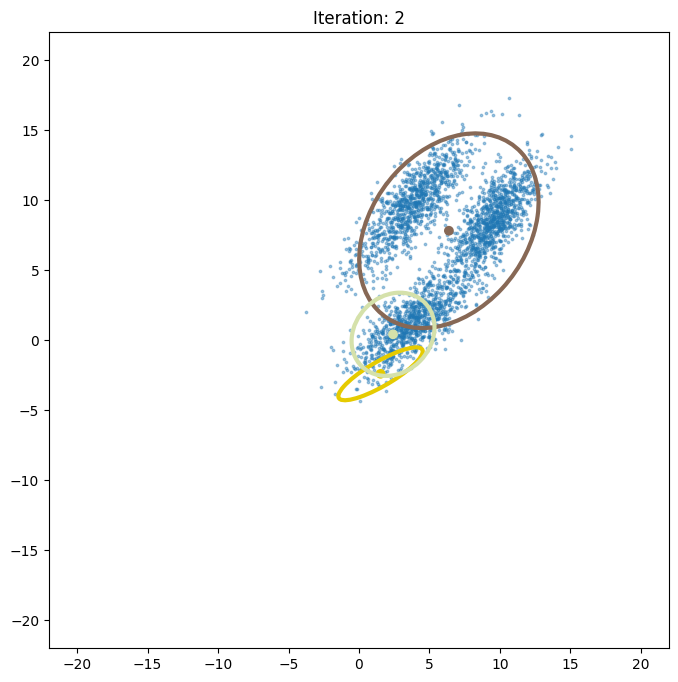

Iteration: 3, log-likelihood: -15502.8492


<Figure size 640x480 with 0 Axes>

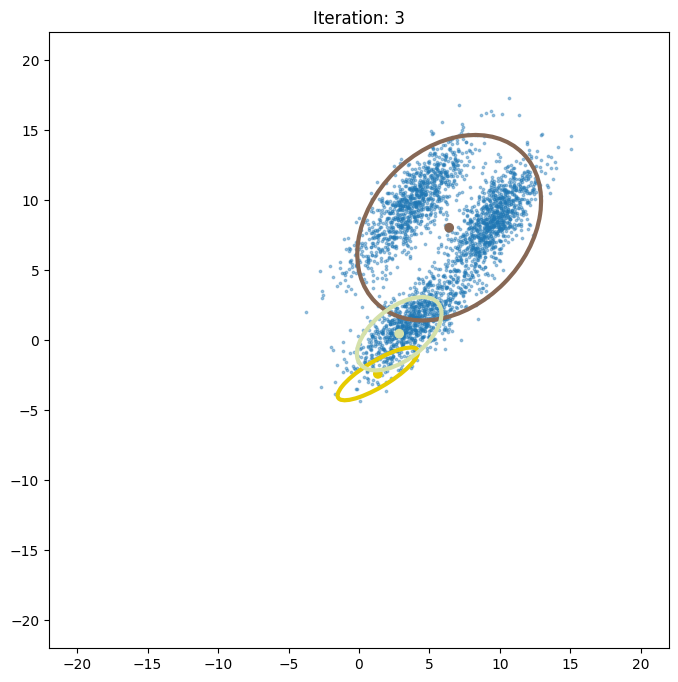

Iteration: 4, log-likelihood: -15407.9800


<Figure size 640x480 with 0 Axes>

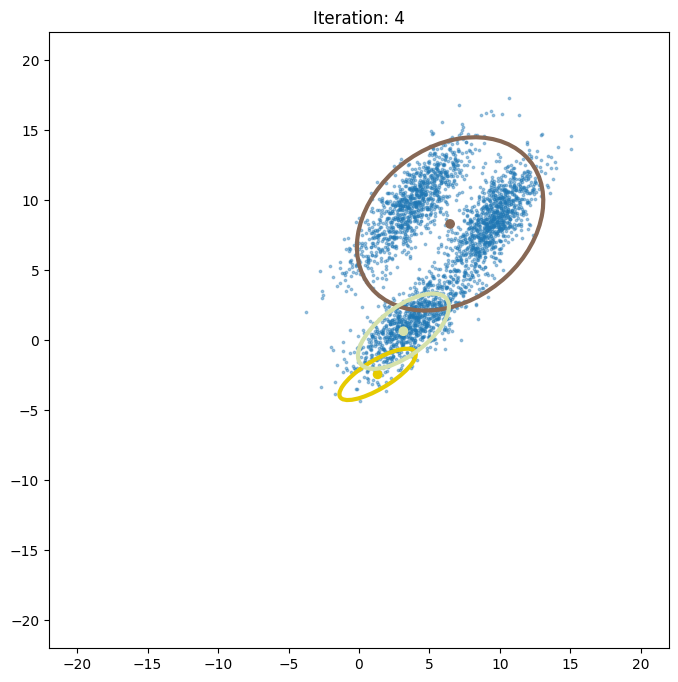

Iteration: 5, log-likelihood: -15345.7227


<Figure size 640x480 with 0 Axes>

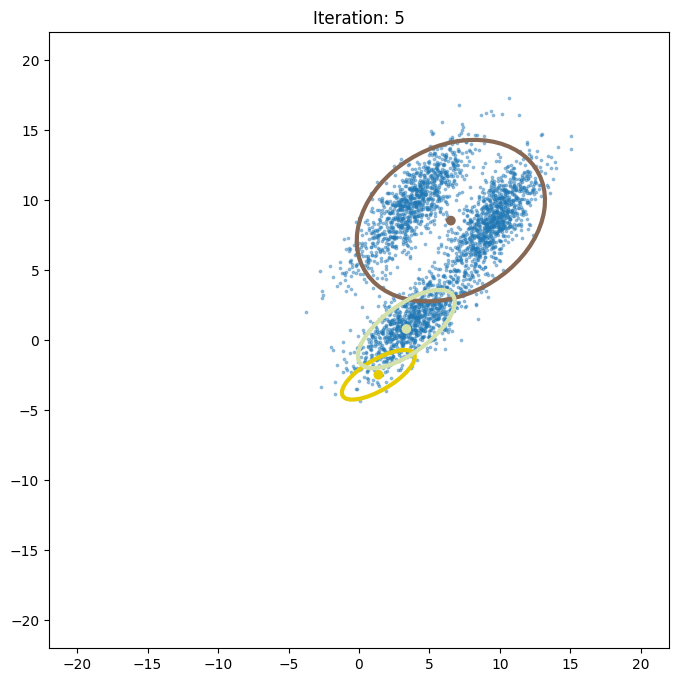

Iteration: 6, log-likelihood: -15307.2685


<Figure size 640x480 with 0 Axes>

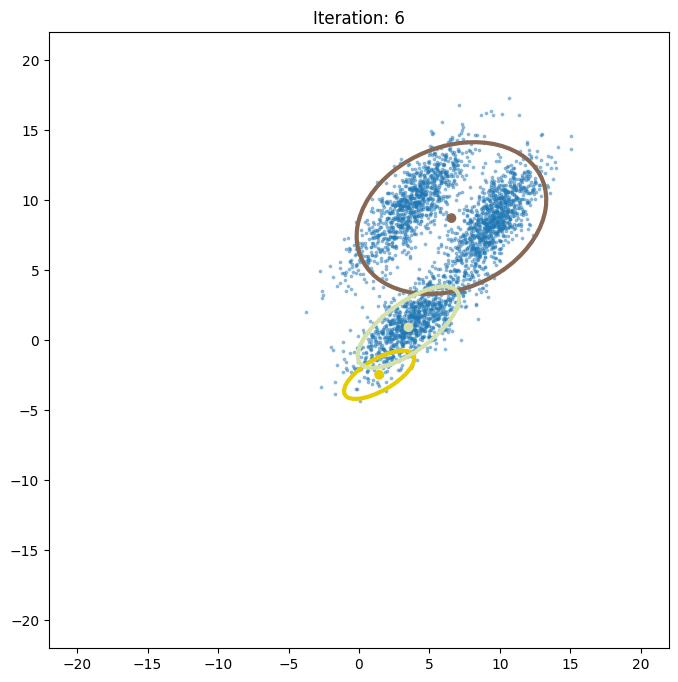

Iteration: 7, log-likelihood: -15285.3888


<Figure size 640x480 with 0 Axes>

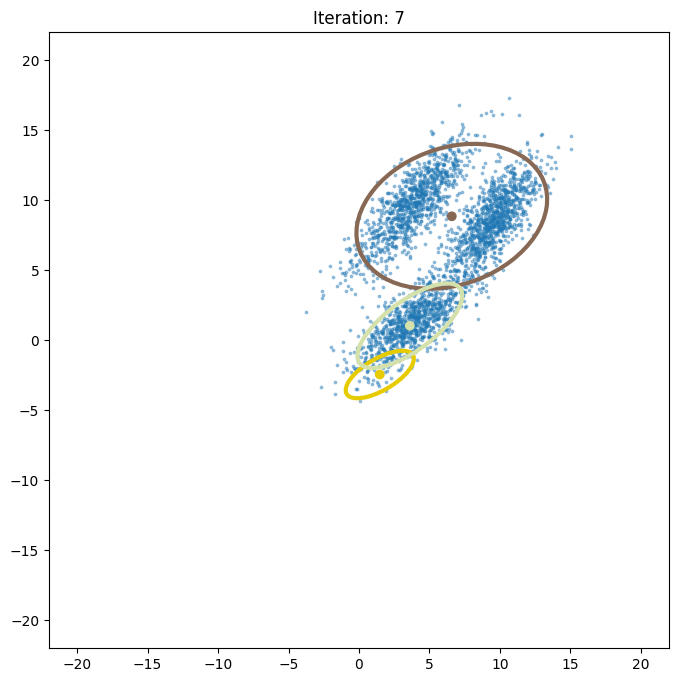

Iteration: 8, log-likelihood: -15273.3377


<Figure size 640x480 with 0 Axes>

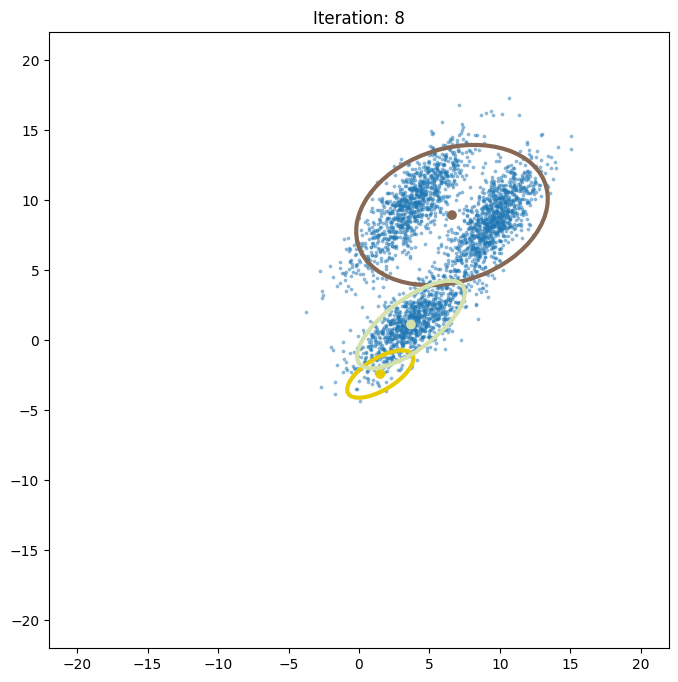

Iteration: 9, log-likelihood: -15266.6527


<Figure size 640x480 with 0 Axes>

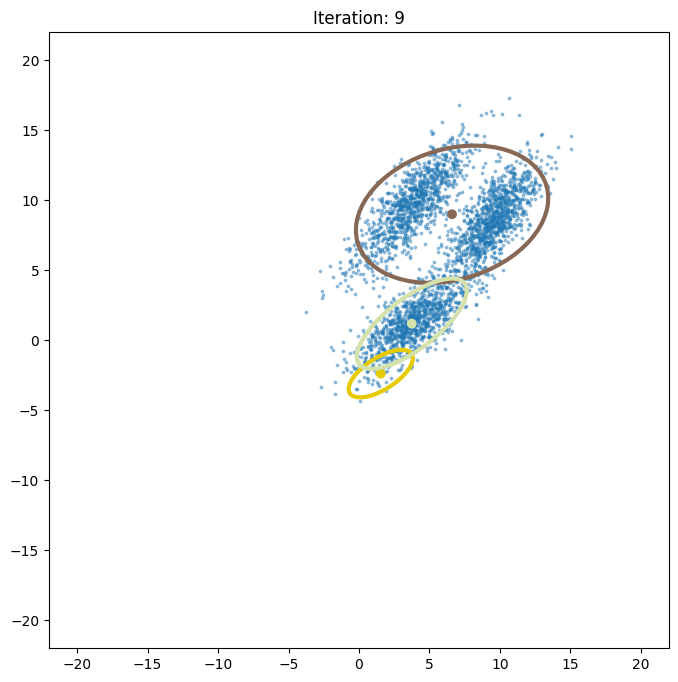

Iteration: 10, log-likelihood: -15262.8387


<Figure size 640x480 with 0 Axes>

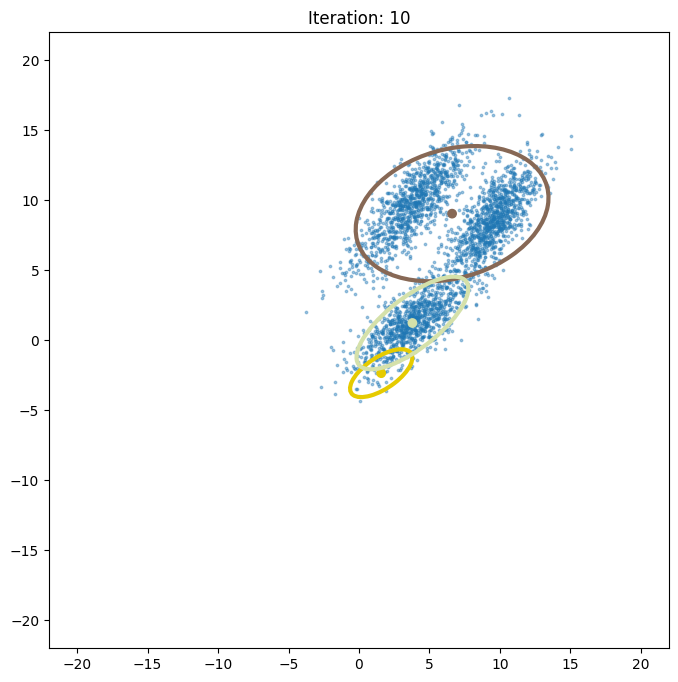

Iteration: 11, log-likelihood: -15260.5815


<Figure size 640x480 with 0 Axes>

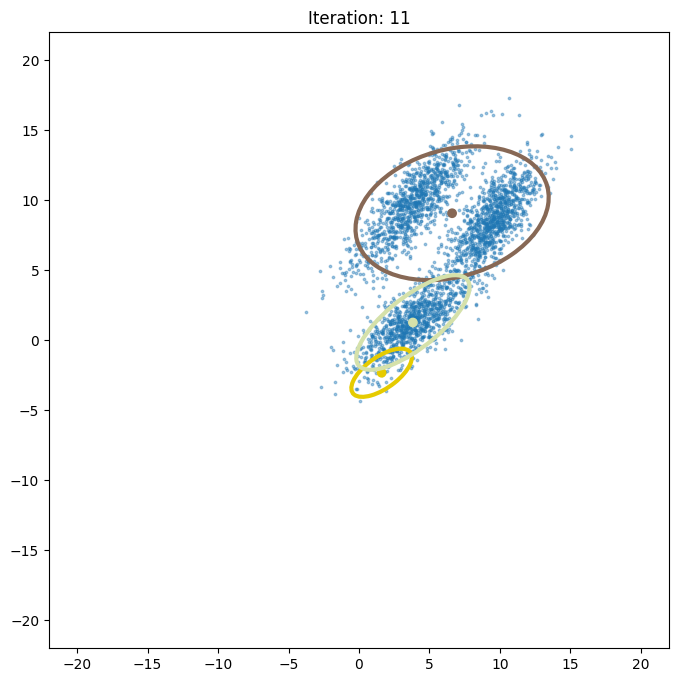

Iteration: 12, log-likelihood: -15259.1938


<Figure size 640x480 with 0 Axes>

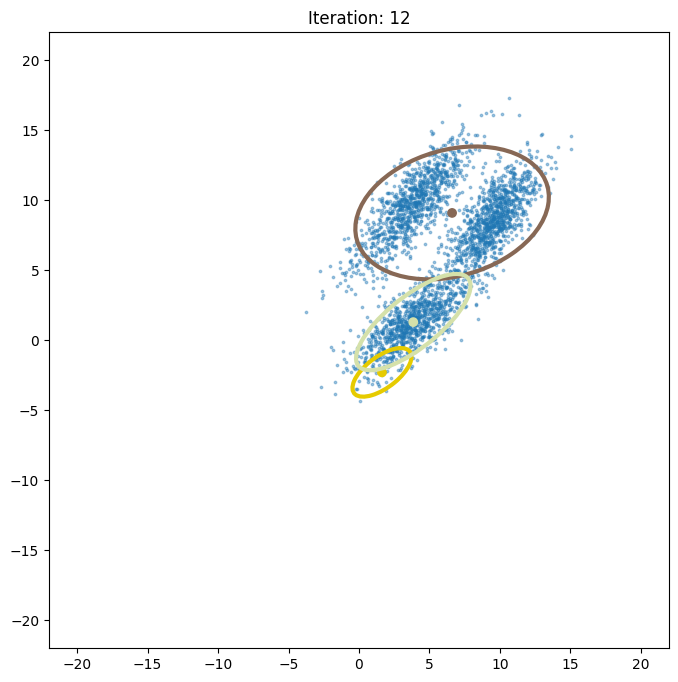

Iteration: 13, log-likelihood: -15258.3090


<Figure size 640x480 with 0 Axes>

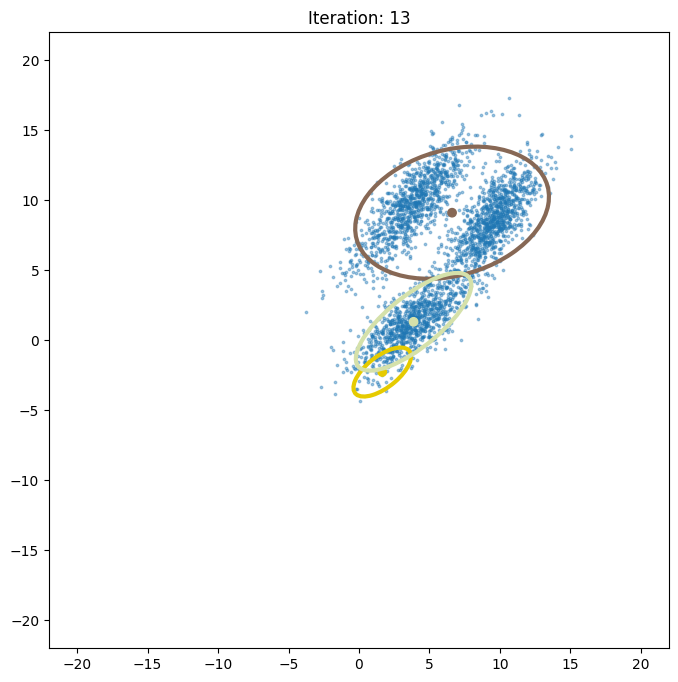

Iteration: 14, log-likelihood: -15257.7255


<Figure size 640x480 with 0 Axes>

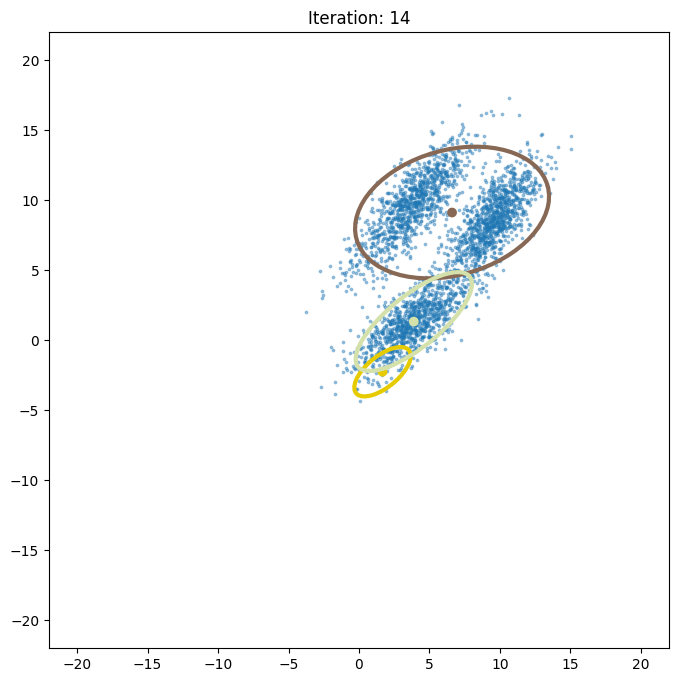

Iteration: 15, log-likelihood: -15257.3288


<Figure size 640x480 with 0 Axes>

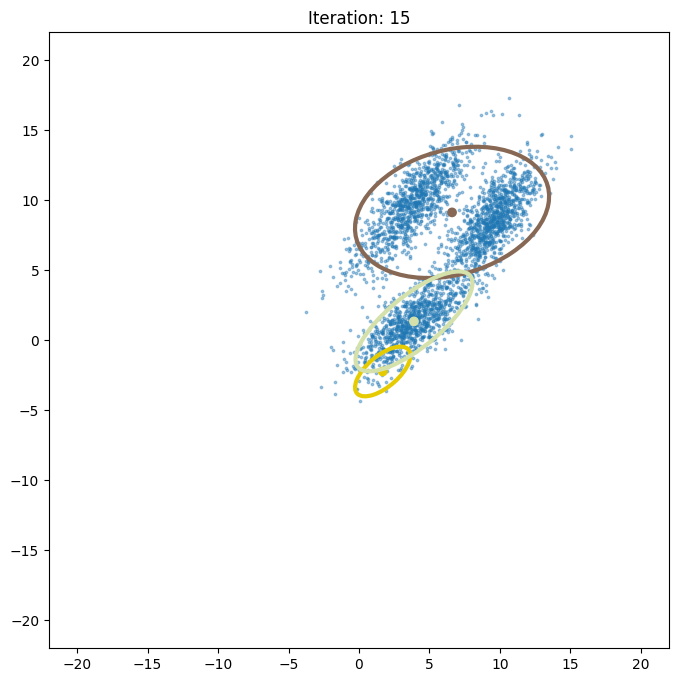

Iteration: 16, log-likelihood: -15257.0514


<Figure size 640x480 with 0 Axes>

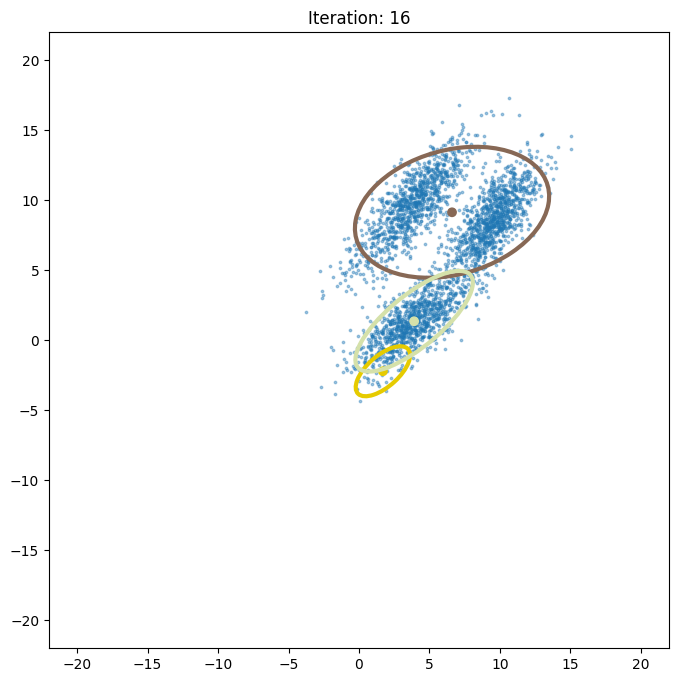

Iteration: 17, log-likelihood: -15256.8526


<Figure size 640x480 with 0 Axes>

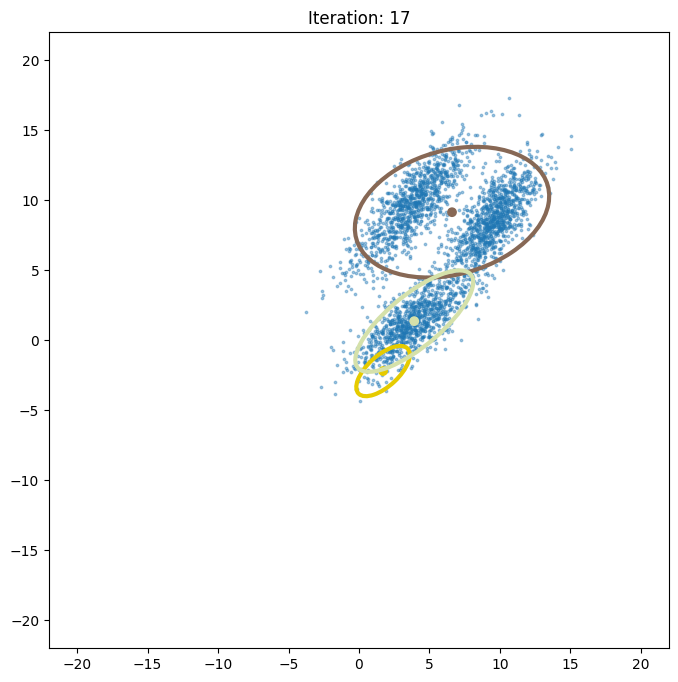

Iteration: 18, log-likelihood: -15256.7067


<Figure size 640x480 with 0 Axes>

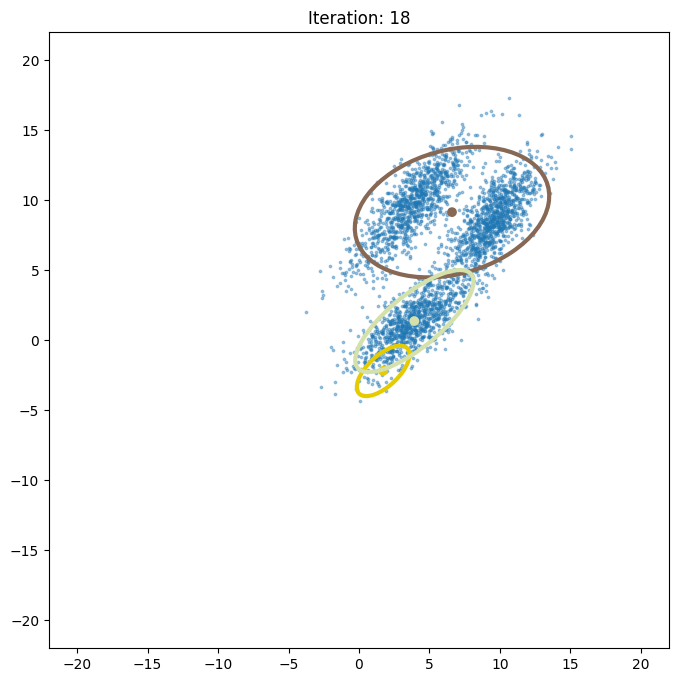

Iteration: 19, log-likelihood: -15256.5974


<Figure size 640x480 with 0 Axes>

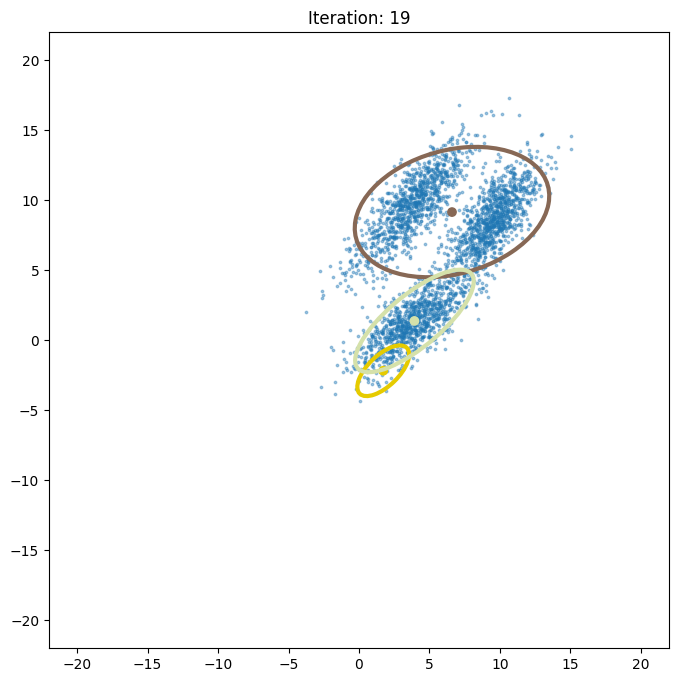

Iteration: 20, log-likelihood: -15256.5139


<Figure size 640x480 with 0 Axes>

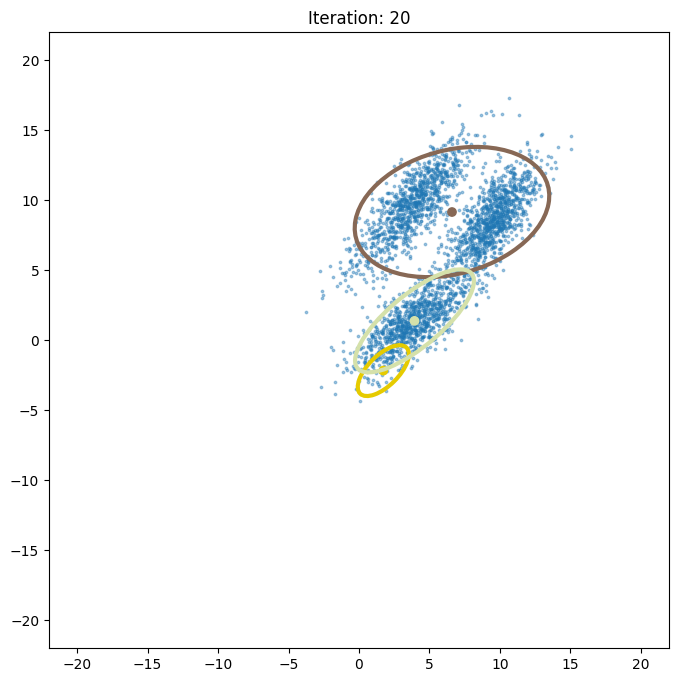

<Figure size 640x480 with 0 Axes>

In [8]:
# Training the GMM using EM

# Initialize EM algo with data (use X_example1)
gmm.init_em(X_example1)

num_iters = 20
# Saving log-likelihood
log_likelihood = [gmm.log_likelihood(X_example1)]
# plotting
plot("Iteration:  0")
for e in range(num_iters):
    # E-step
    gmm.e_step()
    # M-step
    gmm.m_step()
    # Computing log-likelihood
    log_likelihood.append(gmm.log_likelihood(X_example1))
    print("Iteration: {}, log-likelihood: {:.4f}".format(e+1, log_likelihood[-1]))
    # plotting
    plot(title="Iteration: " + str(e+1))

## Bài tập tự thực hành 1

In [9]:
iris = load_iris()
X_iris = iris['data']
y_iris = iris['target']

iris_df = pd.DataFrame(X_iris, columns=iris['feature_names'])
iris_df['target'] = y_iris

print(f"Loaded Iris dataset: X_iris.shape = {X_iris.shape}, iris_df.shape = {iris_df.shape}")
iris_df.head()

Loaded Iris dataset: X_iris.shape = (150, 4), iris_df.shape = (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Iteration 0, log-likelihood: -7390.0008
Iteration 1, log-likelihood: -485.5978
Iteration 2, log-likelihood: -461.0196
Iteration 3, log-likelihood: -459.3762
Iteration 4, log-likelihood: -458.4157
Iteration 3, log-likelihood: -459.3762
Iteration 4, log-likelihood: -458.4157
Iteration 5, log-likelihood: -457.0442
Iteration 6, log-likelihood: -455.3521
Iteration 7, log-likelihood: -451.8720
Iteration 8, log-likelihood: -447.8134
Iteration 5, log-likelihood: -457.0442
Iteration 6, log-likelihood: -455.3521
Iteration 7, log-likelihood: -451.8720
Iteration 8, log-likelihood: -447.8134
Iteration 9, log-likelihood: -446.6110
Iteration 10, log-likelihood: -446.5216
Iteration 9, log-likelihood: -446.6110
Iteration 10, log-likelihood: -446.5216
Iteration 11, log-likelihood: -446.4618
Iteration 12, log-likelihood: -446.3957
Iteration 13, log-likelihood: -446.3180
Iteration 14, log-likelihood: -446.2256
Iteration 11, log-likelihood: -446.4618
Iteration 12, log-likelihood: -446.3957
Iteration 13, lo

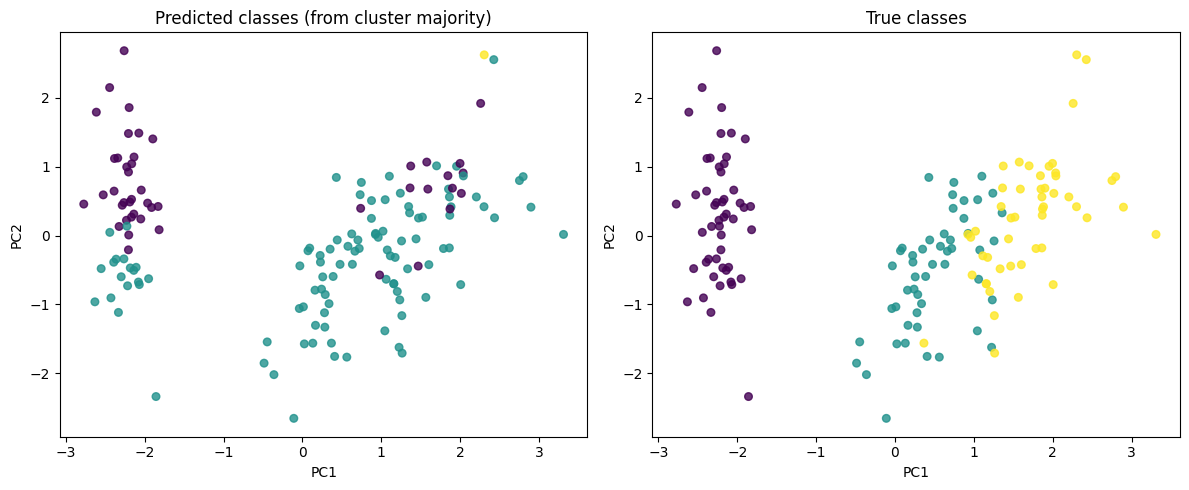

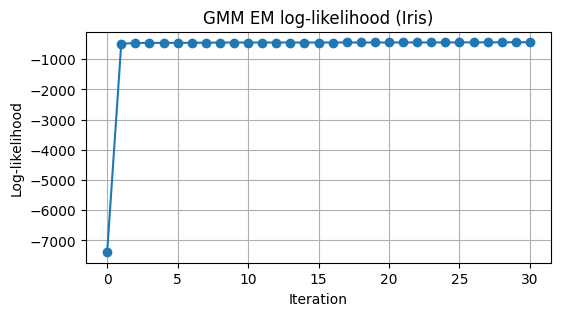

In [10]:
# Prepare data (exclude the target column)
feature_cols = iris['feature_names']
X = iris_df[feature_cols].values
y = iris_df['target'].values

# Standardize
scaler_iris = StandardScaler()
X_scaled = scaler_iris.fit_transform(X)

# Initialize GMM for Iris (k=3)
gmm_iris = GMM(k=3, dim=X_scaled.shape[1])
# Initialize EM
gmm_iris.init_em(X_scaled)

# Run EM
num_iters_iris = 30
log_likelihoods = [gmm_iris.log_likelihood(X_scaled)]
print(f"Iteration 0, log-likelihood: {log_likelihoods[-1]:.4f}")
for e in range(num_iters_iris):
    gmm_iris.e_step()
    gmm_iris.m_step()
    ll = gmm_iris.log_likelihood(X_scaled)
    log_likelihoods.append(ll)
    print(f"Iteration {e+1}, log-likelihood: {ll:.4f}")

# Get cluster assignments (hard labels from posterior responsibilities)
labels_iris = np.argmax(gmm_iris.z, axis=1)

# Map each cluster to the majority true class
cluster_to_class = {}
for c in np.unique(labels_iris):
    idxs = np.where(labels_iris == c)[0]
    majority_class = Counter(y[idxs]).most_common(1)[0][0]
    cluster_to_class[c] = majority_class

# Build predicted labels based on majority mapping
y_pred = np.array([cluster_to_class[l] for l in labels_iris])

# Metrics
acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)
print('\n Results:')
print(f'  - Accuracy: {acc:.4f}')
print('  - Confusion Matrix (rows=true, cols=pred):')
print(cm)
print('\n  - Classification Report:')
print(classification_report(y, y_pred))

# Visualization: PCA 2D scatter of true vs predicted clusters
pca2 = PCA(n_components=2, random_state=42)
X2 = pca2.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Predicted clusters (colored by mapped class)
scatter = axes[0].scatter(X2[:,0], X2[:,1], c=y_pred, cmap='viridis', s=30, alpha=0.8)
axes[0].set_title('Predicted classes (from cluster majority)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# True classes
scatter2 = axes[1].scatter(X2[:,0], X2[:,1], c=y, cmap='viridis', s=30, alpha=0.8)
axes[1].set_title('True classes')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

# Plot log-likelihood over iterations
plt.figure(figsize=(6,3))
plt.plot(range(len(log_likelihoods)), log_likelihoods, marker='o')
plt.title('GMM EM log-likelihood (Iris)')
plt.xlabel('Iteration')
plt.ylabel('Log-likelihood')
plt.grid(True)
plt.show()

## Bài tập tự thực hành 2

K-means inertia: 22182.34
K-means silhouette score: 0.5190
Adjusted Rand Index (GMM vs KMeans): 0.4717
Normalized Mutual Information (GMM vs KMeans): 0.5549

Contingency GMM -> KMeans mapping (counts):
  GMM cluster 0: {np.int32(1): 6}
  GMM cluster 1: {np.int32(0): 910, np.int32(1): 82, np.int32(2): 994}
  GMM cluster 2: {np.int32(2): 42, np.int32(1): 966}


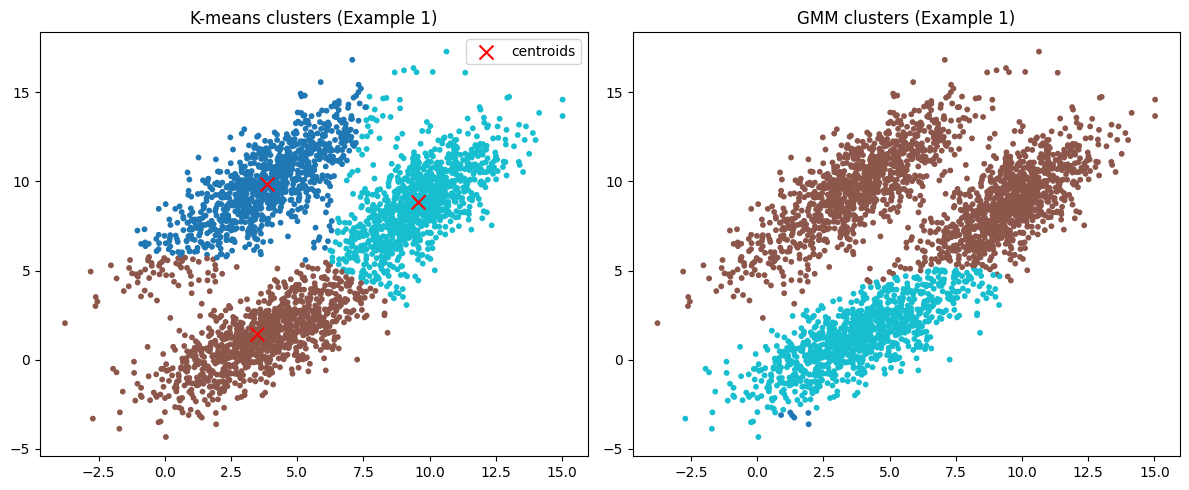


Giải thích kết quả:
 - K-means tối ưu cho cụm hình cầu/đồng đều; nếu cụm có hình dạng eliptic hoặc khác nhau về phương sai, GMM có thể mô tả tốt hơn.
 - Inertia nhỏ và silhouette cao cho thấy clustering K-means hợp lý; nhưng ARI / NMI so sánh với GMM cho thấy mức tương đồng giữa 2 phương pháp (0..1).
 - Nếu GMM và K-means cho kết quả khác nhau: GMM sử dụng covariance (độ rộng, hướng) để model cluster, K-means chỉ dùng centroid và khoảng cách Euclidean.

Bài tập 2 hoàn tất: K-means đã chạy trên dữ liệu synthetic và so sánh ban đầu đã được thực hiện.


In [12]:
# Ensure the synthetic data X_example1 exists (from example 1)
try:
    X_example1
except NameError:
    raise RuntimeError('Dữ liệu X_example1 (synthetic from Example 1) không được tìm thấy. Hãy chạy ô tạo dữ liệu Example 1 trước (gen_data).')

# 1. Chạy K-means (k=3)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_example1)

print(f"K-means inertia: {kmeans.inertia_:.2f}")
print(f"K-means silhouette score: {silhouette_score(X_example1, labels_kmeans):.4f}")

# 2. So sánh với GMM (nếu đã được train) - chỉ khi GMM được train trên cùng dữ liệu
if 'gmm' in globals() and hasattr(gmm, 'z'):
    labels_gmm = np.argmax(gmm.z, axis=1)
    # Check that the GMM was trained on the same number of samples as X_example1
    try:
        gmm_n = gmm.data.shape[0]
    except Exception:
        gmm_n = None
    kmeans_n = X_example1.shape[0]

    if gmm_n == kmeans_n:
        ari = adjusted_rand_score(labels_gmm, labels_kmeans)
        nmi = normalized_mutual_info_score(labels_gmm, labels_kmeans)
        print(f"Adjusted Rand Index (GMM vs KMeans): {ari:.4f}")
        print(f"Normalized Mutual Information (GMM vs KMeans): {nmi:.4f}")
        # Contingency table
        from collections import Counter
        print('\nContingency GMM -> KMeans mapping (counts):')
        for g in np.unique(labels_gmm):
            cnt = Counter(labels_kmeans[labels_gmm == g])
            print(f'  GMM cluster {g}: {dict(cnt)}')
    else:
        print(f"\n GMM và K-means không được train trên cùng dữ liệu (GMM n={gmm_n}, KMeans n={kmeans_n}). Bỏ phần so sánh ARI/NMI.")
        print("Nếu muốn so sánh, hãy train GMM lại trên cùng dữ liệu hoặc recreate the synthetic X and re-run GMM.")
else:
    print('\n GMM model or responsibilities not found — bỏ phần so sánh GMM.')

# 3. Visualization: K-means clusters vs GMM clusters (if available)
fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].scatter(X_example1[:,0], X_example1[:,1], c=labels_kmeans, cmap='tab10', s=10)
axes[0].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker='x', color='red', s=100, label='centroids')
axes[0].set_title('K-means clusters (Example 1)')
axes[0].legend()

if 'gmm' in globals() and hasattr(gmm, 'z') and (hasattr(gmm, 'data') and gmm.data.shape[0] == X_example1.shape[0]):
    labels_gmm = np.argmax(gmm.z, axis=1)
    axes[1].scatter(X_example1[:,0], X_example1[:,1], c=labels_gmm, cmap='tab10', s=10)
    axes[1].set_title('GMM clusters (Example 1)')
else:
    axes[1].text(0.5, 0.5, 'GMM not available or trained on different data', ha='center')
    axes[1].set_title('GMM clusters (not available)')

plt.tight_layout()
plt.show()

# 4. Short explanation (printed)
print('\nGiải thích kết quả:')
print(' - K-means tối ưu cho cụm hình cầu/đồng đều; nếu cụm có hình dạng eliptic hoặc khác nhau về phương sai, GMM có thể mô tả tốt hơn.')
print(' - Inertia nhỏ và silhouette cao cho thấy clustering K-means hợp lý; nhưng ARI / NMI so sánh với GMM cho thấy mức tương đồng giữa 2 phương pháp (0..1).')
print(' - Nếu GMM và K-means cho kết quả khác nhau: GMM sử dụng covariance (độ rộng, hướng) để model cluster, K-means chỉ dùng centroid và khoảng cách Euclidean.')
print('\nBài tập 2 hoàn tất: K-means đã chạy trên dữ liệu synthetic và so sánh ban đầu đã được thực hiện.')


## 2.2. Xây dựng thuật toán từ sklearn

In [15]:
data = pd.read_csv("D:\\Workspace\\HUS\\Machine Learning\\10. GMM\\shopping-data.csv", header=0, index_col=0)

print(data.shape)
data.head()
# Lấy ra thu nhập va điểm shopping
X = data.iloc[:, 2:4].values
# Chuẩn hoá dữ liệu
std = MinMaxScaler()
X_std = std.fit_transform(X)
print(X_std.shape)

(200, 4)
(200, 2)


In [16]:
# Khởi tạo đối tượng mô hình GaussianMixture
gm = GaussianMixture(n_components=5,
covariance_type='full',
random_state=0)

gm.fit(X_std)
print('means: \n', gm.means_)
print('covariances: \n ', gm.covariances_)

means: 
 [[0.33368985 0.49394756]
 [0.60502531 0.15433196]
 [0.58393969 0.82673863]
 [0.09861098 0.21597752]
 [0.0829305  0.80743088]]
covariances: 
  [[[ 0.00613567 -0.00231927]
  [-0.00231927  0.0051635 ]]

 [[ 0.01818446  0.00433814]
  [ 0.00433814  0.00873064]]

 [[ 0.01808598 -0.00031096]
  [-0.00031096  0.0091568 ]]

 [[ 0.00453005  0.00255303]
  [ 0.00255303  0.01918353]]

 [[ 0.00337483 -0.0001437 ]
  [-0.0001437   0.01026088]]]


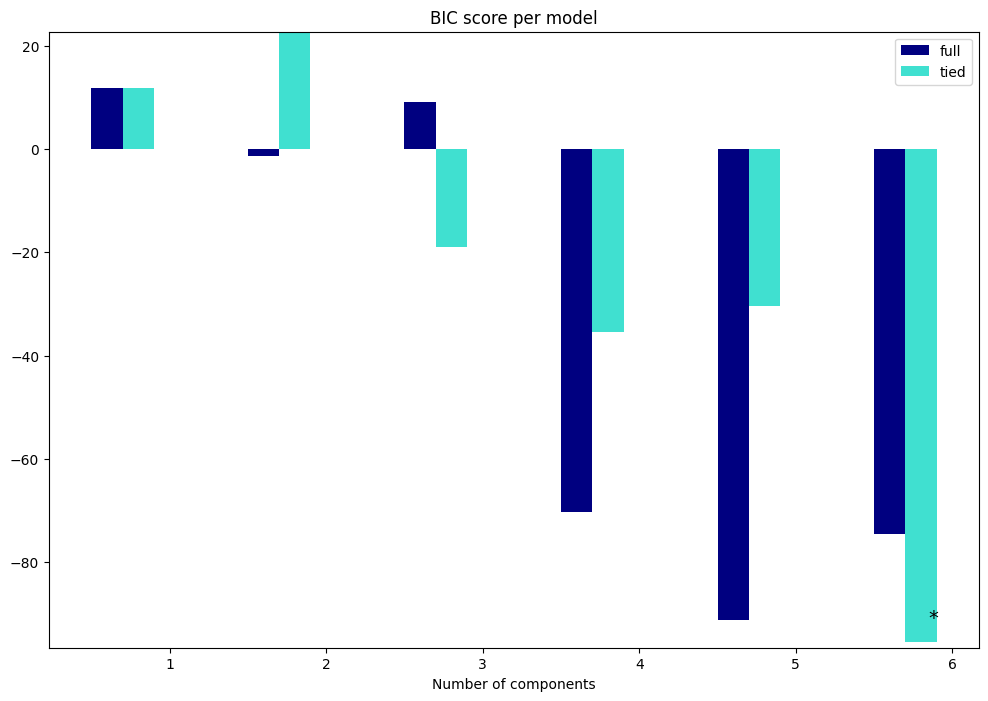

In [18]:
lowest_bic = np.inf
bic = []
n_components_range = range(1, 7)
# cv_types = ['spherical', 'tied', 'diag', 'full']
cv_types = ['full', 'tied']
for cv_type in cv_types:
    for n_components in n_components_range:
    # Fit Gaussian mixture theo phương pháp huấn luyện EM
        gmm = GaussianMixture(n_components=n_components,
        covariance_type=cv_type)
        gmm.fit(X_std)
        bic.append(gmm.bic(X_std))
        # Gán model có BIC scores thấp nhất là model tốt nhất
        if bic[-1] < lowest_bic:
            lowest_bic = bic[-1]
            best_gmm = gmm
bic = np.array(bic)
color_iter = itertools.cycle(['navy', 'turquoise'])
clf = best_gmm
bars = []
# Vẽ biểu đồ BIC scores
plt.figure(figsize=(12, 8))
for i, (cv_type, color) in enumerate(zip(cv_types, color_iter)):
    xpos = np.array(n_components_range) + .2 * (i - 2)
    bars.append(plt.bar(xpos, bic[i * len(n_components_range):(i + 1) * len(n_components_range)],width=.2, color=color))
plt.xticks(n_components_range)
plt.ylim([bic.min() * 1.01 - .01 * bic.max(), bic.max()])
plt.title('BIC score per model')
xpos = np.mod(bic.argmin(), len(n_components_range)) + .65 +\
.2 * np.floor(bic.argmin() / len(n_components_range))
plt.text(xpos, bic.min() * 0.97 + .03 * bic.max(), '*', fontsize=14)
plt.xlabel('Number of components')
plt.legend([b[0] for b in bars], cv_types)

In [21]:
def _plot_kmean_scatter(X, labels):
    '''
    X: dữ liệu đầu vào (n_samples, 2)
    labels: nhãn dự báo (n_samples,)
    '''
    # lựa chọn màu sắc
    unique_labels = np.unique(labels)
    num_classes = len(unique_labels)
    palette = np.array(sns.color_palette("hls", num_classes))

    # vẽ biểu đồ scatter
    fig, ax = plt.subplots(figsize=(12, 8))

    # Ensure integer label indices for palette indexing
    labels_int = labels.astype(int)

    # If palette indexing expects 0..num_classes-1 but labels may be arbitrary, remap
    if not np.array_equal(unique_labels, np.arange(num_classes)):
        # create mapping from original label -> 0..num_classes-1
        label_map = {lab: i for i, lab in enumerate(unique_labels)}
        labels_mapped = np.array([label_map[l] for l in labels_int])
    else:
        labels_mapped = labels_int

    sc = ax.scatter(X[:, 0], X[:, 1], lw=0, s=40, c=palette[labels_mapped])

    # thêm nhãn cho mỗi cluster (vị trí median); skip nếu cluster rỗng
    txts = []
    for i, lab in enumerate(unique_labels):
        pts = X[labels_int == lab]
        if pts.shape[0] == 0:
            continue
        # Vẽ text tên cụm tại trung vị của mỗi cụm
        xtext, ytext = np.median(pts, axis=0)
        txt = ax.text(xtext, ytext, str(i), fontsize=24)

        txt.set_path_effects([
            PathEffects.Stroke(linewidth=5, foreground="w"),
            PathEffects.Normal()
        ])
        txts.append(txt)

    ax.set_title('t-sne visualization')
    plt.show()


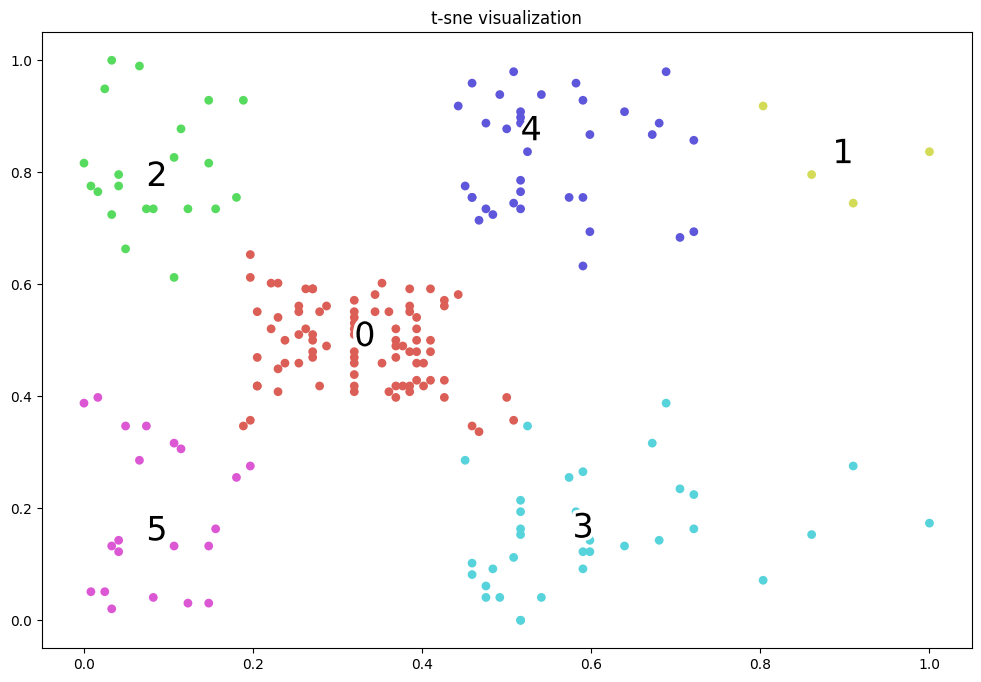

In [22]:
labels = best_gmm.predict(X_std)
_plot_kmean_scatter(X_std, labels)

## 2.3. Ví dụ mở rộng

Loading: D:\Workspace\HUS\Machine Learning\10. GMM\Sales_Transactions_Dataset_Weekly.csv
Raw shape: (811, 107)
Detected ID column: Product_Code
Using feature source: normalized columns (detected)
Number of feature columns used: 52
Feature sample names: ['Normalized 0', 'Normalized 1', 'Normalized 2', 'Normalized 3', 'Normalized 4', 'Normalized 5']

Evaluating k range (5..15) — this may take a while
 k= 5  silhouette=0.0515  inertia=28423.21  bic=136103.08
 k= 6  silhouette=0.0460  inertia=28047.52  bic=149484.11
 k= 7  silhouette=0.0424  inertia=27850.64  bic=152905.62
 k= 8  silhouette=0.0365  inertia=27591.07  bic=156435.38
 k= 9  silhouette=0.0288  inertia=27379.35  bic=163749.90
 k=10  silhouette=0.0276  inertia=27239.91  bic=159073.64
 k=11  silhouette=0.0286  inertia=27154.97  bic=167843.95
 k=12  silhouette=0.0307  inertia=26965.69  bic=166516.00
 k=13  silhouette=0.0283  inertia=26692.29  bic=156233.78
 k=14  silhouette=0.0240  inertia=26613.16  bic=166761.94
 k=15  silhouette=

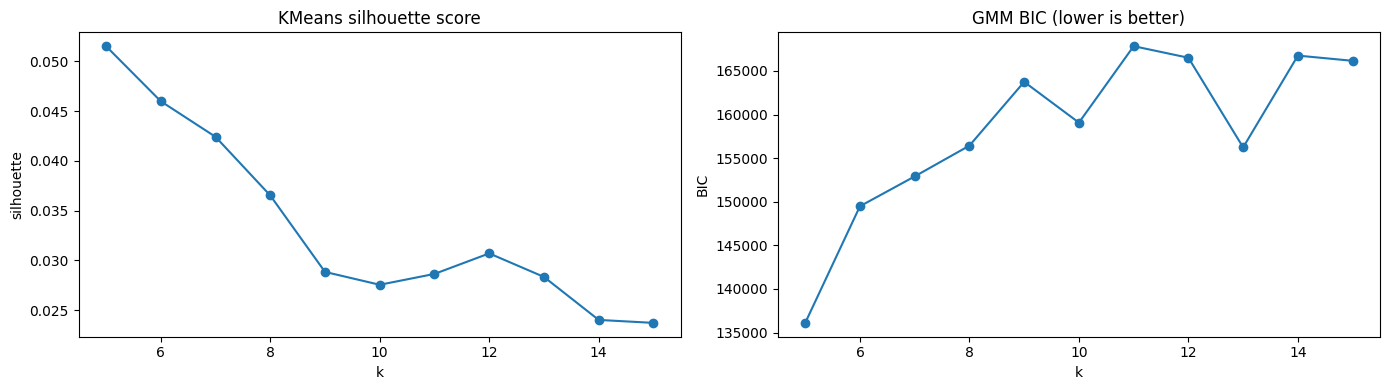


Suggested k by silhouette: 5
Suggested k by BIC: 5
Chosen final_k = 5

Cluster sizes (KMeans):
cluster_kmeans
0    244
1    114
2    128
3    148
4    177
Name: count, dtype: int64

Cluster sizes (GMM):
cluster_gmm
0     14
1    168
2    298
3    208
4    123
Name: count, dtype: int64


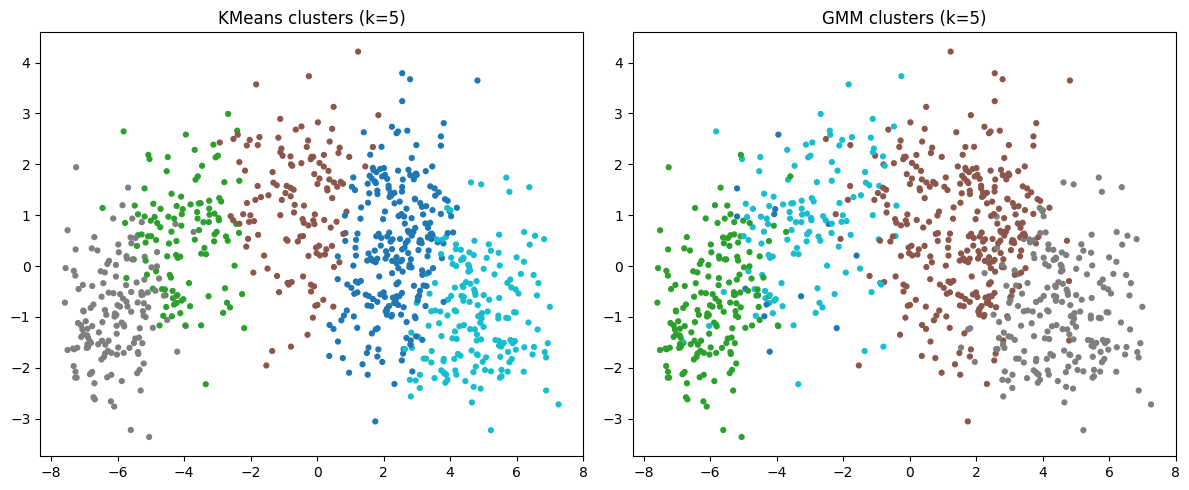


Saved cluster assignments to D:\Workspace\HUS\Machine Learning\10. GMM\sales_clusters_assigned.csv

Done — summary:
 - Features used: 52 columns (normalized columns (detected))
 - Final k chosen: 5
 - KMeans cluster counts:
cluster_kmeans
0    244
1    114
2    128
3    148
4    177
Name: count, dtype: int64
 - GMM cluster counts:
cluster_gmm
0     14
1    168
2    298
3    208
4    123
Name: count, dtype: int64


In [ ]:
sales_path = r"D:\Workspace\HUS\Machine Learning\10. GMM\Sales_Transactions_Dataset_Weekly.csv"
print('Loading:', sales_path)
df_sales = pd.read_csv(sales_path, header=0)
print('Raw shape:', df_sales.shape)

# Identify ID column (first column) and candidate feature columns
id_col = df_sales.columns[0]
all_cols = list(df_sales.columns)
print('Detected ID column:', id_col)

# Heuristic: prefer normalized/scaled columns if present (look for 'scaled','norm','standard')
norm_candidates = [c for c in all_cols if re.search(r'scaled|norm|standard|zscore|z_score|normalized', c, re.I)]
# Heuristic for week columns: names containing 'week' or 0..51 in header positions
week_candidates = [c for c in all_cols if re.search(r'week', c, re.I)]

# fallback: treat columns 1..52 as weeks if there are enough columns
if len(df_sales.columns) >= 53:
    cols_by_pos = list(df_sales.columns[1:53])
else:
    cols_by_pos = list(df_sales.columns[1:])

# Choose features: prefer norm_candidates (>=52), else week_candidates (>=52), else cols_by_pos
if len(norm_candidates) >= 52:
    feat_cols = norm_candidates[:52]
    source_used = 'normalized columns (detected)'
elif len(week_candidates) >= 52:
    feat_cols = week_candidates[:52]
    source_used = 'week columns (detected by name)'
elif len(cols_by_pos) >= 52:
    feat_cols = cols_by_pos[:52]
    source_used = 'week columns (by position)'
else:
    # fallback to all except ID
    feat_cols = [c for c in all_cols if c != id_col]
    source_used = 'fallback: all non-ID columns'

print('Using feature source:', source_used)
print('Number of feature columns used:', len(feat_cols))
print('Feature sample names:', feat_cols[:6])

# Prepare matrix
X = df_sales[feat_cols].astype(float).values
# Standardize for clustering
scaler_sales = StandardScaler()
X_scaled_sales = scaler_sales.fit_transform(X)

# Evaluate k in 5..15 using KMeans (silhouette) and GMM (BIC)
ks = list(range(5, 16))
sil_scores = []
bic_scores = []
iner = []

print('\nEvaluating k range (5..15) — this may take a while')
for k in ks:
    # KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled_sales)
    sil = silhouette_score(X_scaled_sales, labels_k) if k > 1 else np.nan
    sil_scores.append(sil)
    iners = km.inertia_
    iner.append(iners)

    # GMM (fit & bic)
    try:
        gm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=3)
        gm.fit(X_scaled_sales)
        bic_scores.append(gm.bic(X_scaled_sales))
    except Exception as e:
        bic_scores.append(np.nan)
        print(f'  Warning: GMM failed for k={k}:', e)

    print(f' k={k:2d}  silhouette={sil_scores[-1]:.4f}  inertia={iner[-1]:.2f}  bic={bic_scores[-1]:.2f}')

# Plot metrics
fig, ax = plt.subplots(1, 2, figsize=(14,4))
ax[0].plot(ks, sil_scores, marker='o')
ax[0].set_title('KMeans silhouette score')
ax[0].set_xlabel('k')
ax[0].set_ylabel('silhouette')

ax[1].plot(ks, bic_scores, marker='o')
ax[1].set_title('GMM BIC (lower is better)')
ax[1].set_xlabel('k')
ax[1].set_ylabel('BIC')
plt.tight_layout()
plt.show()

# Suggest best k by metrics
best_k_sil = ks[int(np.nanargmax(sil_scores))]
best_k_bic = ks[int(np.nanargmin(bic_scores))]
print('\nSuggested k by silhouette:', best_k_sil)
print('Suggested k by BIC:', best_k_bic)

# Decide final k: prefer silhouette result but show both
final_k = best_k_sil
print('Chosen final_k =', final_k)

# Fit final models and attach labels
km_final = KMeans(n_clusters=final_k, random_state=42, n_init=20)
df_sales['cluster_kmeans'] = km_final.fit_predict(X_scaled_sales)

gm_final = GaussianMixture(n_components=final_k, covariance_type='full', random_state=42, n_init=5)
df_sales['cluster_gmm'] = gm_final.fit_predict(X_scaled_sales)

# Show cluster sizes
print('\nCluster sizes (KMeans):')
print(df_sales['cluster_kmeans'].value_counts().sort_index())
print('\nCluster sizes (GMM):')
print(df_sales['cluster_gmm'].value_counts().sort_index())

# PCA 2D visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_scaled_sales)

fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].scatter(X2[:,0], X2[:,1], c=df_sales['cluster_kmeans'], cmap='tab10', s=12)
axes[0].set_title(f'KMeans clusters (k={final_k})')
axes[1].scatter(X2[:,0], X2[:,1], c=df_sales['cluster_gmm'], cmap='tab10', s=12)
axes[1].set_title(f'GMM clusters (k={final_k})')
plt.tight_layout()
plt.show()

# Save results
out_path = r"D:\Workspace\HUS\Machine Learning\10. GMM\sales_clusters_assigned.csv"
df_sales.to_csv(out_path, index=False)
print('\nSaved cluster assignments to', out_path)

print('\nDone — summary:')
print(f' - Features used: {len(feat_cols)} columns ({source_used})')
print(f' - Final k chosen: {final_k}')
print(' - KMeans cluster counts:')
print(df_sales["cluster_kmeans"].value_counts().sort_index())
print(' - GMM cluster counts:')
print(df_sales["cluster_gmm"].value_counts().sort_index())
